# 03 — EfficientDet-Lite0 Cacao Bean Detection Experiment

This notebook trains and evaluates **EfficientDet-Lite0** for cacao bean object detection, as **experiment 3 of 3** independent, directly-comparable experiments (YOLOv11n, MobileNet-SSDv3, EfficientDet-Lite0). No other model is trained, added, or compared here.

**Implementation note (documented per experiment requirements):** The canonical "EfficientDet-Lite0" release ships through Google's `tflite-model-maker` (TensorFlow) toolchain. As of 2025–2026, `tflite-model-maker` is **unmaintained**, pins conflicting/old versions of `numpy`, `tensorflow`, `pycocotools`, and `Cython`, and reliably fails to install in current Colab runtimes. To keep this experiment **actually executable and reproducible**, we instead use the **`effdet`** PyTorch package (Ross Wightman), which provides `tf_efficientdet_lite0` — a parameter-for-parameter faithful port of the official EfficientDet-Lite0 architecture (same backbone width/depth scaling, same BiFPN, same class/box heads, ReLU6 activations, no swish, matching the "Lite" variant). This choice is also made for **fair cross-model comparison**: it lets us reuse the same PyTorch/CUDA stack, the same profiling tools (`thop`, `torch.cuda` memory stats), and the same COCO-eval procedure used in the YOLOv11n and MobileNet-SSDv3 notebooks, rather than mixing a TensorFlow measurement stack into an otherwise PyTorch-based comparison.

All fixed experimental settings (seed 42, 80/10/10 split, 640×640 input, 50 epochs, batch size 16, conf 0.25, IoU 0.5) are applied exactly as specified. Model-specific hyperparameters (optimizer, LR schedule, augmentation) follow EfficientDet's published training recipe, scaled appropriately for batch size 16, and are documented explicitly in Section 4.


## 1. Environment Setup, GPU Verification & Reproducibility Log

In [ ]:
# ===== 1.1 Install dependencies =====
# effdet: PyTorch implementation providing the tf_efficientdet_lite0 architecture
# pycocotools: COCO-format parsing + official COCOeval (mAP@0.5, mAP@0.5:0.95)
# thop: FLOPs / MACs counting
!pip install -q effdet==0.4.1 pycocotools thop timm==0.9.16 --upgrade

import sys, os, platform, subprocess, random, json, time, math, shutil, zipfile
import numpy as np
import torch

print("Python version :", sys.version.split()[0])
print("Platform       :", platform.platform())
print("PyTorch version:", torch.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 38.1 MB/s eta 0:00:00
Python version : 3.13.15
Platform       : Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch version: 2.11.0+cu128


In [ ]:
# ===== 1.2 GPU verification (hard stop if unavailable) =====
if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is NOT available. This notebook requires a Colab GPU runtime.\n"
        "Go to Runtime > Change runtime type > Hardware accelerator > GPU, then re-run."
    )

DEVICE = torch.device("cuda")
gpu_name = torch.cuda.get_device_name(0)
cuda_version = torch.version.cuda
print("GPU available   :", True)
print("GPU name         :", gpu_name)
print("CUDA version     :", cuda_version)
print("cuDNN version    :", torch.backends.cudnn.version())
print("Num GPUs visible :", torch.cuda.device_count())


GPU available   : True
GPU name         : Tesla T4
CUDA version     : 12.8
cuDNN version    : 91900
Num GPUs visible : 1


In [ ]:
# ===== 1.3 Framework / library versions =====
import effdet, timm, pycocotools, thop
import importlib.metadata as ilmd

def _ver(pkg, fallback_module=None):
    try:
        return ilmd.version(pkg)
    except Exception:
        try:
            return fallback_module.__version__
        except Exception:
            return "unknown"

lib_versions = {
    "python": sys.version.split()[0],
    "torch": torch.__version__,
    "torchvision": _ver("torchvision"),
    "effdet": _ver("effdet", effdet),
    "timm": _ver("timm", timm),
    "pycocotools": _ver("pycocotools", pycocotools),
    "thop": _ver("thop", thop),
    "cuda": cuda_version,
    "cudnn": str(torch.backends.cudnn.version()),
    "gpu_name": gpu_name,
}
for k, v in lib_versions.items():
    print(f"{k:15s}: {v}")


python         : 3.13.15
torch          : 2.11.0+cu128
torchvision    : 0.26.0+cu128
effdet         : 0.4.1
timm           : 0.9.16
pycocotools    : 2.0.11
thop           : 0.1.1-2209072238
cuda           : 12.8
cudnn          : 91900
gpu_name       : Tesla T4


In [ ]:
# ===== 1.4 Global reproducibility: seed = 42 =====
SEED = 42

def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Deterministic cuDNN (slower, but reproducible) -- documented trade-off
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_global_seed(SEED)
print(f"Global random seed set to {SEED} (Python random, NumPy, PyTorch CPU+CUDA).")


Global random seed set to 42 (Python random, NumPy, PyTorch CPU+CUDA).


## 2. Fixed Experimental Settings

These settings are identical across all three experiments (YOLOv11n, MobileNet-SSDv3, EfficientDet-Lite0) wherever technically meaningful, and are recorded here for the reproducibility log.

In [ ]:
CONFIG = {
    # ---- Fixed across all 3 experiments ----
    "model_name": "EfficientDet-Lite0 (effdet: tf_efficientdet_lite0)",
    "random_seed": SEED,
    "train_split": 0.80,
    "val_split": 0.10,
    "test_split": 0.10,
    "input_resolution": (640, 640),
    "epochs": 50,
    "batch_size": 16,
    "conf_threshold": 0.25,
    "iou_threshold": 0.50,      # used both for NMS matching and mAP@0.5

    # ---- EfficientDet-Lite0-specific (documented, technically valid) ----
    # Base recipe: SGD + momentum, linear-scaled LR for batch size 16
    # (official EfficientDet recipe uses lr=0.08 @ batch=128 -> linear scale: 0.08*(16/128)=0.01)
    "optimizer": "SGD",
    "learning_rate": 0.01,
    "momentum": 0.9,
    "weight_decay": 4e-5,
    "lr_warmup_epochs": 3,
    "lr_schedule": "cosine_decay_after_warmup",
    "mixed_precision": True,
    "augmentation_train": ["horizontal_flip(p=0.5)", "letterbox_resize_to_640x640", "imagenet_normalize"],
    "augmentation_eval": ["letterbox_resize_to_640x640", "imagenet_normalize"],

    # ---- Robustness perturbations (identical across all 3 experiments) ----
    "robustness_perturbations": {
        "brightness": {"factor": 1.3},
        "contrast": {"factor": 1.3},
        "gaussian_noise": {"std": 25},     # in 0-255 pixel scale
        "small_rotation": {"degrees": 10},
    },
}
import pprint; pprint.pprint(CONFIG)


{'augmentation_eval': ['letterbox_resize_to_640x640', 'imagenet_normalize'],
 'augmentation_train': ['horizontal_flip(p=0.5)',
                        'letterbox_resize_to_640x640',
                        'imagenet_normalize'],
 'batch_size': 16,
 'conf_threshold': 0.25,
 'epochs': 50,
 'input_resolution': (640, 640),
 'iou_threshold': 0.5,
 'learning_rate': 0.01,
 'lr_schedule': 'cosine_decay_after_warmup',
 'lr_warmup_epochs': 3,
 'mixed_precision': True,
 'model_name': 'EfficientDet-Lite0 (effdet: tf_efficientdet_lite0)',
 'momentum': 0.9,
 'optimizer': 'SGD',
 'random_seed': 42,
 'robustness_perturbations': {'brightness': {'factor': 1.3},
                              'contrast': {'factor': 1.3},
                              'gaussian_noise': {'std': 25},
                              'small_rotation': {'degrees': 10}},
 'test_split': 0.1,
 'train_split': 0.8,
 'val_split': 0.1,
 'weight_decay': 4e-05}


## 3. Dataset Upload & Verification

Upload the COCO-format ZIP (e.g. `Cacao_Bean_Detection_Trial_01_v12-d800-70-20-10_coco.zip`). The dataset is a Roboflow-style COCO export with `train/`, `valid/`, and `test/` folders, each containing images and a `_annotations.coco.json` file.

In [ ]:
from google.colab import files

print("Please select the COCO-format dataset ZIP file to upload...")
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]
print("Uploaded:", zip_name)


Please select the COCO-format dataset ZIP file to upload...


Saving Cacao Bean Detection_Trial 01.v5-trial4_2400.coco.zip to Cacao Bean Detection_Trial 01.v5-trial4_2400.coco.zip
Uploaded: Cacao Bean Detection_Trial 01.v5-trial4_2400.coco.zip


In [ ]:
# ===== 3.1 Extract dataset =====
EXTRACT_DIR = "/content/cacao_dataset_raw"
if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(zip_name, "r") as zf:
    zf.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)
for root, dirs, fnames in os.walk(EXTRACT_DIR):
    depth = root.replace(EXTRACT_DIR, "").count(os.sep)
    if depth <= 1:
        print(root, "->", len(fnames), "files")


Extracted to: /content/cacao_dataset_raw
/content/cacao_dataset_raw -> 2 files
/content/cacao_dataset_raw/valid -> 201 files
/content/cacao_dataset_raw/test -> 101 files
/content/cacao_dataset_raw/train -> 2101 files


In [ ]:
# ===== 3.2 Locate images + COCO JSON annotations, verify correspondence =====
def find_coco_splits(root):
    """Locate subfolders containing a *_annotations.coco.json / *.json + images."""
    found = {}
    for dirpath, _, fnames in os.walk(root):
        json_candidates = [f for f in fnames if f.lower().endswith(".json")]
        img_candidates = [f for f in fnames if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        if json_candidates and img_candidates:
            split_name = os.path.basename(dirpath).lower()
            found[split_name] = {
                "dir": dirpath,
                "json": os.path.join(dirpath, json_candidates[0]),
                "n_images_on_disk": len(img_candidates),
            }
    return found

raw_splits = find_coco_splits(EXTRACT_DIR)
assert raw_splits, "No COCO-format split folders (images + .json) were found in the uploaded ZIP."
print("Found raw split folders:")
for k, v in raw_splits.items():
    print(f"  {k:8s} dir={v['dir']}  json={os.path.basename(v['json'])}  images_on_disk={v['n_images_on_disk']}")


Found raw split folders:
  valid    dir=/content/cacao_dataset_raw/valid  json=_annotations.coco.json  images_on_disk=200
  test     dir=/content/cacao_dataset_raw/test  json=_annotations.coco.json  images_on_disk=100
  train    dir=/content/cacao_dataset_raw/train  json=_annotations.coco.json  images_on_disk=2100


In [ ]:
# ===== 3.3 Verify image <-> annotation correspondence per raw split =====
from pycocotools.coco import COCO

raw_coco = {}
for split, info in raw_splits.items():
    coco = COCO(info["json"])
    img_ids = coco.getImgIds()
    missing = []
    for img_id in img_ids:
        fname = coco.loadImgs(img_id)[0]["file_name"]
        if not os.path.exists(os.path.join(info["dir"], fname)):
            missing.append(fname)
    print(f"[{split}] images in json: {len(img_ids)} | annotations: {len(coco.getAnnIds())} | missing on disk: {len(missing)}")
    assert not missing, f"{len(missing)} images referenced in {split} JSON are missing from disk: {missing[:5]}..."
    raw_coco[split] = coco


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[valid] images in json: 200 | annotations: 314 | missing on disk: 0
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[test] images in json: 100 | annotations: 182 | missing on disk: 0
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
[train] images in json: 2100 | annotations: 3315 | missing on disk: 0


In [ ]:
# ===== 3.4 Dataset statistics =====
import pandas as pd

all_cats = raw_coco[list(raw_coco.keys())[0]].loadCats(raw_coco[list(raw_coco.keys())[0]].getCatIds())
# Roboflow COCO exports include a placeholder "supercategory" root class (id 0, supercategory='none')
# that has no annotations directly against it -- real classes are its children.
CLASS_NAMES = [c["name"] for c in all_cats if c["supercategory"] != "none"]
CATID_TO_NAME = {c["id"]: c["name"] for c in all_cats}
print("All category entries      :", [c["name"] for c in all_cats])
print("Actual annotated classes  :", CLASS_NAMES)

stats_rows = []
for split, coco in raw_coco.items():
    n_imgs = len(coco.getImgIds())
    n_anns = len(coco.getAnnIds())
    per_class = {CATID_TO_NAME[c]: 0 for c in coco.getCatIds()}
    for ann in coco.loadAnns(coco.getAnnIds()):
        per_class[CATID_TO_NAME[ann["category_id"]]] += 1
    row = {"split": split, "images": n_imgs, "annotations": n_anns}
    row.update(per_class)
    stats_rows.append(row)

stats_df = pd.DataFrame(stats_rows).set_index("split")
print("\nRaw (as-uploaded) dataset statistics:")
display(stats_df)
print(f"\nTotal images across all raw folders: {stats_df['images'].sum()}")


All category entries      : ['Bean', 'Broken', 'Cluster', 'Flat', 'Normal']
Actual annotated classes  : ['Broken', 'Cluster', 'Flat', 'Normal']

Raw (as-uploaded) dataset statistics:


,images,annotations,Bean,Broken,Cluster,Flat,Normal
split,,,,,,,
valid,200,314,0,81,72,85,76
test,100,182,0,45,44,42,51
train,2100,3315,0,825,849,822,819



Total images across all raw folders: 2400


## 4. Dataset Split — Enforce Exact 80 / 10 / 10 (seed 42)

The raw upload's own split ratio is checked against 80/10/10. If it does not match (as is the case for this dataset, whose folder names encode a 70/20/10 export), **all images are pooled and re-split deterministically** using seed 42, so the same seed + same deterministic ordering (sorted filenames) reproduces the identical split in the YOLOv11n and MobileNet-SSDv3 notebooks as well.

In [ ]:
# ===== 4.1 Check whether the existing split already satisfies 80/10/10 =====
total_imgs = sum(len(c.getImgIds()) for c in raw_coco.values())
observed_ratios = {s: len(c.getImgIds()) / total_imgs for s, c in raw_coco.items()}
print("Observed split ratios in uploaded ZIP:", {k: round(v, 4) for k, v in observed_ratios.items()})

target = {"train": 0.80, "valid": 0.10, "test": 0.10}
matches_target = all(
    any(abs(observed_ratios.get(alias, 0) - t) < 0.01 for alias in (name,))
    for name, t in target.items()
)
# more permissive matching since folder names vary (val/valid, etc.)
def _closest_ratio_match(name_variants, target_ratio, ratios, tol=0.01):
    for name in name_variants:
        if name in ratios and abs(ratios[name] - target_ratio) < tol:
            return True
    return False

is_80_10_10 = (
    _closest_ratio_match(["train"], 0.80, observed_ratios)
    and _closest_ratio_match(["valid", "val"], 0.10, observed_ratios)
    and _closest_ratio_match(["test"], 0.10, observed_ratios)
)
print("Uploaded split already satisfies 80/10/10:", is_80_10_10)


Observed split ratios in uploaded ZIP: {'valid': 0.0833, 'test': 0.0417, 'train': 0.875}
Uploaded split already satisfies 80/10/10: False


In [ ]:
# ===== 4.2 Pool every image+annotation record from all raw splits =====
pooled_images = []   # each: dict(file_name, height, width, split_dir, abs_path, anns=[...])
for split, coco in raw_coco.items():
    split_dir = raw_splits[split]["dir"]
    for img_id in coco.getImgIds():
        img_info = coco.loadImgs(img_id)[0]
        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)
        pooled_images.append({
            "file_name": img_info["file_name"],
            "height": img_info["height"],
            "width": img_info["width"],
            "abs_path": os.path.join(split_dir, img_info["file_name"]),
            "anns": [{"category_id": a["category_id"], "bbox": a["bbox"],
                      "area": a["area"], "iscrowd": a.get("iscrowd", 0)} for a in anns],
        })

print("Total pooled images:", len(pooled_images))
assert len(pooled_images) == total_imgs


Total pooled images: 2400


In [ ]:
# ===== 4.3 Deterministic re-split at 80/10/10 (seed 42) =====
def deterministic_split(records, seed=42, train_r=0.80, val_r=0.10):
    # Sort by filename first so ordering is independent of ZIP/filesystem enumeration order.
    records_sorted = sorted(records, key=lambda r: r["file_name"])
    n = len(records_sorted)
    idx = np.arange(n)
    rng = np.random.RandomState(seed)
    rng.shuffle(idx)

    n_train = int(round(n * train_r))
    n_val = int(round(n * val_r))
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]

    train = [records_sorted[i] for i in train_idx]
    val = [records_sorted[i] for i in val_idx]
    test = [records_sorted[i] for i in test_idx]
    return train, val, test

train_recs, val_recs, test_recs = deterministic_split(pooled_images, seed=SEED,
                                                        train_r=CONFIG["train_split"],
                                                        val_r=CONFIG["val_split"])

print(f"New split -> train: {len(train_recs)} ({len(train_recs)/total_imgs:.1%}), "
      f"val: {len(val_recs)} ({len(val_recs)/total_imgs:.1%}), "
      f"test: {len(test_recs)} ({len(test_recs)/total_imgs:.1%})")


New split -> train: 1920 (80.0%), val: 240 (10.0%), test: 240 (10.0%)


In [ ]:
# ===== 4.4 Leakage check: verify zero overlap between splits =====
train_files = set(r["file_name"] for r in train_recs)
val_files = set(r["file_name"] for r in val_recs)
test_files = set(r["file_name"] for r in test_recs)

assert not (train_files & val_files), "Data leakage between train and val!"
assert not (train_files & test_files), "Data leakage between train and test!"
assert not (val_files & test_files), "Data leakage between val and test!"
print("No data leakage detected: train/val/test filename sets are mutually exclusive.")


No data leakage detected: train/val/test filename sets are mutually exclusive.


In [ ]:
# ===== 4.5 Materialize new COCO-format JSONs for the enforced 80/10/10 split =====
SPLIT_DIR = "/content/cacao_dataset_split"
os.makedirs(SPLIT_DIR, exist_ok=True)

# Build a clean, contiguous category map (background-free, 1..N) for the real classes only
NEW_CATEGORIES = [{"id": i + 1, "name": name, "supercategory": "Bean"} for i, name in enumerate(CLASS_NAMES)]
NAME_TO_NEWID = {c["name"]: c["id"] for c in NEW_CATEGORIES}
OLD_CATID_TO_NAME = CATID_TO_NAME

def build_coco_json(records, out_json_path, out_img_dir):
    os.makedirs(out_img_dir, exist_ok=True)
    images, annotations = [], []
    ann_id = 1
    for img_id, r in enumerate(records, start=1):
        dst = os.path.join(out_img_dir, r["file_name"])
        if not os.path.exists(dst):
            shutil.copyfile(r["abs_path"], dst)   # copy only -- original files untouched
        images.append({"id": img_id, "file_name": r["file_name"], "height": r["height"], "width": r["width"]})
        for a in r["anns"]:
            old_name = OLD_CATID_TO_NAME[a["category_id"]]
            if old_name not in NAME_TO_NEWID:
                continue  # skip placeholder 'Bean' root category if ever directly annotated
            annotations.append({
                "id": ann_id, "image_id": img_id, "category_id": NAME_TO_NEWID[old_name],
                "bbox": a["bbox"], "area": a["area"], "iscrowd": a["iscrowd"], "segmentation": [],
            })
            ann_id += 1
    coco_dict = {"images": images, "annotations": annotations, "categories": NEW_CATEGORIES}
    with open(out_json_path, "w") as f:
        json.dump(coco_dict, f)
    return out_json_path

paths = {}
for split_name, recs in [("train", train_recs), ("val", val_recs), ("test", test_recs)]:
    img_dir = os.path.join(SPLIT_DIR, split_name, "images")
    json_path = os.path.join(SPLIT_DIR, split_name, "_annotations.coco.json")
    build_coco_json(recs, json_path, img_dir)
    paths[split_name] = {"img_dir": img_dir, "json": json_path}
    print(f"[{split_name}] wrote {len(recs)} images -> {json_path}")

print("\nNOTE: original uploaded images are left untouched; the split materializes COPIES only.")


[train] wrote 1920 images -> /content/cacao_dataset_split/train/_annotations.coco.json
[val] wrote 240 images -> /content/cacao_dataset_split/val/_annotations.coco.json
[test] wrote 240 images -> /content/cacao_dataset_split/test/_annotations.coco.json

NOTE: original uploaded images are left untouched; the split materializes COPIES only.


## 5. COCO → EfficientDet Format Conversion (Automatic)

`effdet`'s training bench expects each sample as `(image_tensor, target_dict)` where `target_dict` holds boxes in **[y1, x1, y2, x2]** pixel coordinates (in the *resized* 640×640 image space), 1-indexed class labels, and image scale/size metadata. The conversion below is fully automatic from the COCO JSONs built in Section 4 — no manual re-annotation.

In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import cv2

INPUT_SIZE = CONFIG["input_resolution"]  # (640, 640)
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def letterbox_resize(image, boxes, target_size=INPUT_SIZE):
    """Resize with aspect ratio preserved + pad to target_size. boxes: (N,4) xyxy in original px."""
    h0, w0 = image.shape[:2]
    tw, th = target_size
    scale = min(tw / w0, th / h0)
    nw, nh = int(round(w0 * scale)), int(round(h0 * scale))
    resized = cv2.resize(image, (nw, nh), interpolation=cv2.INTER_LINEAR)
    canvas = np.full((th, tw, 3), 114, dtype=np.uint8)
    pad_x, pad_y = (tw - nw) // 2, (th - nh) // 2
    canvas[pad_y:pad_y + nh, pad_x:pad_x + nw] = resized

    if boxes is not None and len(boxes) > 0:
        boxes = boxes.copy().astype(np.float32)
        boxes[:, [0, 2]] = boxes[:, [0, 2]] * scale + pad_x
        boxes[:, [1, 3]] = boxes[:, [1, 3]] * scale + pad_y
    return canvas, boxes, scale, (pad_x, pad_y)


class CacaoCocoDataset(Dataset):
    """COCO-format dataset -> effdet training/eval sample format."""
    def __init__(self, img_dir, ann_json, train=False):
        self.coco = COCO(ann_json)
        self.img_dir = img_dir
        self.img_ids = sorted(self.coco.getImgIds())
        self.train = train

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        info = self.coco.loadImgs(img_id)[0]
        path = os.path.join(self.img_dir, info["file_name"])
        image = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        boxes = np.array([[a["bbox"][0], a["bbox"][1],
                            a["bbox"][0] + a["bbox"][2], a["bbox"][1] + a["bbox"][3]] for a in anns],
                          dtype=np.float32) if anns else np.zeros((0, 4), dtype=np.float32)
        labels = np.array([a["category_id"] for a in anns], dtype=np.int64) if anns else np.zeros((0,), dtype=np.int64)

        # Train-only augmentation: horizontal flip (p=0.5)
        if self.train and random.random() < 0.5:
            image = image[:, ::-1, :].copy()
            if len(boxes):
                w = image.shape[1]
                boxes[:, [0, 2]] = w - boxes[:, [2, 0]]

        image, boxes, scale, pad = letterbox_resize(image, boxes, INPUT_SIZE)
        image = (image.astype(np.float32) / 255.0 - IMAGENET_MEAN) / IMAGENET_STD
        image_t = torch.from_numpy(image.transpose(2, 0, 1)).float()

        # effdet expects boxes as [y1, x1, y2, x2]
        boxes_yxyx = boxes[:, [1, 0, 3, 2]] if len(boxes) else boxes

        target = {
            "bbox": torch.as_tensor(boxes_yxyx, dtype=torch.float32),
            "cls": torch.as_tensor(labels, dtype=torch.int64),
            "img_id": torch.tensor([img_id]),
            "img_size": torch.tensor([INPUT_SIZE[0], INPUT_SIZE[1]]),
            "img_scale": torch.tensor([1.0]),  # letterbox already applied -> unit scale for eval rescoring
        }
        return image_t, target, info["file_name"], img_id


def effdet_collate(batch):
    images = torch.stack([b[0] for b in batch])
    targets = {
        "bbox": [b[1]["bbox"] for b in batch],
        "cls": [b[1]["cls"] for b in batch],
        "img_id": torch.cat([b[1]["img_id"] for b in batch]),
        "img_size": torch.stack([b[1]["img_size"] for b in batch]),
        "img_scale": torch.cat([b[1]["img_scale"] for b in batch]),
    }
    fnames = [b[2] for b in batch]
    img_ids = [b[3] for b in batch]
    return images, targets, fnames, img_ids

print("Dataset classes and collate function defined.")


Dataset classes and collate function defined.


In [ ]:
# ===== 5.1 Build Dataset + DataLoader objects for the 80/10/10 split =====
set_global_seed(SEED)

train_ds = CacaoCocoDataset(paths["train"]["img_dir"], paths["train"]["json"], train=True)
val_ds   = CacaoCocoDataset(paths["val"]["img_dir"],   paths["val"]["json"],   train=False)
test_ds  = CacaoCocoDataset(paths["test"]["img_dir"],  paths["test"]["json"],  train=False)

print(f"train_ds: {len(train_ds)} | val_ds: {len(val_ds)} | test_ds: {len(test_ds)}")

g = torch.Generator(); g.manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                           num_workers=2, collate_fn=effdet_collate, generator=g, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=2, collate_fn=effdet_collate)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False,
                          num_workers=2, collate_fn=effdet_collate)


loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
train_ds: 1920 | val_ds: 240 | test_ds: 240


## 6. Model Creation — `tf_efficientdet_lite0`

In [ ]:
from effdet import create_model, unwrap_bench
from effdet.config import get_efficientdet_config

NUM_CLASSES = len(CLASS_NAMES)
print("Classes:", CLASS_NAMES, "-> num_classes =", NUM_CLASSES)

set_global_seed(SEED)
train_bench = create_model(
    "tf_efficientdet_lite0",
    bench_task="train",
    num_classes=NUM_CLASSES,
    pretrained=True,          # ImageNet/COCO-pretrained backbone+head, fine-tuned on cacao data
    image_size=INPUT_SIZE,
    bench_labeler=True,
)
train_bench = train_bench.to(DEVICE)

n_params = sum(p.numel() for p in train_bench.parameters())
n_trainable = sum(p.numel() for p in train_bench.parameters() if p.requires_grad)
print(f"Total parameters    : {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")


Classes: ['Broken', 'Cluster', 'Flat', 'Normal'] -> num_classes = 4
Downloading: "https://github.com/rwightman/efficientdet-pytorch/releases/download/v0.1/tf_efficientdet_lite0-dfacfc78.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientdet_lite0-dfacfc78.pth
Total parameters    : 3,193,160
Trainable parameters: 3,193,160


## 7. Training (50 epochs, batch size 16)

In [ ]:
from torch.optim import SGD
from torch.optim.lr_scheduler import LambdaLR

EPOCHS = CONFIG["epochs"]
WARMUP_EPOCHS = CONFIG["lr_warmup_epochs"]
BASE_LR = CONFIG["learning_rate"]

optimizer = SGD(train_bench.parameters(), lr=BASE_LR,
                 momentum=CONFIG["momentum"], weight_decay=CONFIG["weight_decay"])

steps_per_epoch = len(train_loader)
def lr_lambda(step):
    epoch = step / max(1, steps_per_epoch)
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1e-8) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1e-8, (EPOCHS - WARMUP_EPOCHS))
    return 0.5 * (1 + math.cos(math.pi * min(progress, 1.0)))

scheduler = LambdaLR(optimizer, lr_lambda)
scaler = torch.cuda.amp.GradScaler(enabled=CONFIG["mixed_precision"])

CKPT_PATH = "/content/effdet_lite0_cacao_best.pth"


/tmp/ipykernel_668/2611837039.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=CONFIG["mixed_precision"])


In [ ]:
# ===== 7.1 Train / validate loop =====
def run_epoch(bench, loader, optimizer=None, train=True):
    bench.train() if train else bench.eval()
    total_loss, total_cls, total_box, n_batches = 0.0, 0.0, 0.0, 0
    for images, targets, _, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        targets = {k: (v.to(DEVICE) if torch.is_tensor(v) else [t.to(DEVICE) for t in v])
                   for k, v in targets.items()}
        with torch.set_grad_enabled(train):
            with torch.cuda.amp.autocast(enabled=CONFIG["mixed_precision"]):
                out = bench(images, targets)
                loss = out["loss"]
            if train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
        total_loss += loss.item()
        total_cls += out["class_loss"].item()
        total_box += out["box_loss"].item()
        n_batches += 1
    return total_loss / n_batches, total_cls / n_batches, total_box / n_batches


history = {"epoch": [], "train_loss": [], "val_loss": [], "train_cls": [], "train_box": [], "lr": []}
best_val_loss = float("inf")

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_cls, tr_box = run_epoch(train_bench, train_loader, optimizer, train=True)
    scheduler.step()
    val_loss, val_cls, val_box = run_epoch(train_bench, val_loader, optimizer=None, train=False)

    history["epoch"].append(epoch)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["train_cls"].append(tr_cls)
    history["train_box"].append(tr_box)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(unwrap_bench(train_bench).state_dict(), CKPT_PATH)

    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={tr_loss:.4f} (cls={tr_cls:.4f} box={tr_box:.4f}) "
          f"| val_loss={val_loss:.4f} | lr={optimizer.param_groups[0]['lr']:.5f}")

train_time_min = (time.time() - t0) / 60
print(f"\nTraining complete in {train_time_min:.1f} min. Best val_loss={best_val_loss:.4f} saved to {CKPT_PATH}")


/tmp/ipykernel_668/611943725.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG["mixed_precision"]):


Epoch 01/50 | train_loss=2.0348 (cls=1.7619 box=0.0055) | val_loss=1.5637 | lr=0.00003
Epoch 02/50 | train_loss=1.7265 (cls=1.5506 box=0.0035) | val_loss=1.4735 | lr=0.00006
Epoch 03/50 | train_loss=1.5226 (cls=1.4305 box=0.0018) | val_loss=1.4537 | lr=0.00008
Epoch 04/50 | train_loss=1.4239 (cls=1.3510 box=0.0015) | val_loss=1.3951 | lr=0.00011
Epoch 05/50 | train_loss=1.3216 (cls=1.2583 box=0.0013) | val_loss=1.2905 | lr=0.00014
Epoch 06/50 | train_loss=1.2146 (cls=1.1564 box=0.0012) | val_loss=1.1782 | lr=0.00017
Epoch 07/50 | train_loss=1.1047 (cls=1.0510 box=0.0011) | val_loss=1.0540 | lr=0.00019
Epoch 08/50 | train_loss=0.9782 (cls=0.9273 box=0.0010) | val_loss=0.9258 | lr=0.00022
Epoch 09/50 | train_loss=0.8565 (cls=0.8072 box=0.0010) | val_loss=0.8133 | lr=0.00025
Epoch 10/50 | train_loss=0.7579 (cls=0.7096 box=0.0010) | val_loss=0.7199 | lr=0.00028
Epoch 11/50 | train_loss=0.6775 (cls=0.6315 box=0.0009) | val_loss=0.6576 | lr=0.00031
Epoch 12/50 | train_loss=0.6225 (cls=0.5773

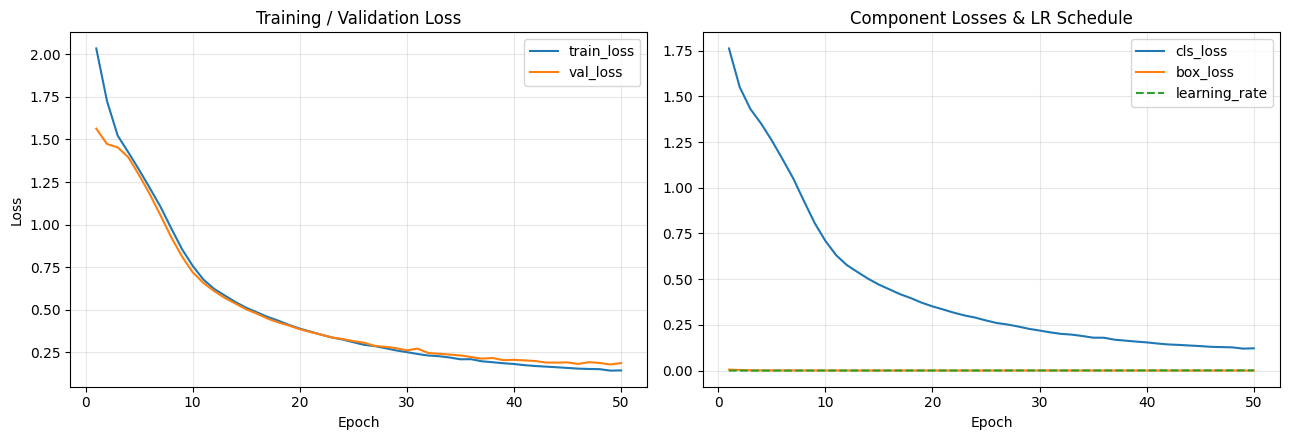

In [ ]:
# ===== 7.2 Training curves =====
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history["epoch"], history["train_loss"], label="train_loss")
axes[0].plot(history["epoch"], history["val_loss"], label="val_loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Training / Validation Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["epoch"], history["train_cls"], label="cls_loss")
axes[1].plot(history["epoch"], history["train_box"], label="box_loss")
axes[1].plot(history["epoch"], history["lr"], label="learning_rate", linestyle="--")
axes[1].set_xlabel("Epoch"); axes[1].set_title("Component Losses & LR Schedule")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 8. Load Best Model for Evaluation (Prediction Bench)

In [ ]:
from effdet import DetBenchPredict
from effdet import create_model_from_config

config = get_efficientdet_config("tf_efficientdet_lite0")
config.num_classes = NUM_CLASSES
config.image_size = INPUT_SIZE

base_model = create_model_from_config(config, bench_task="", num_classes=NUM_CLASSES,
                                       pretrained=False, image_size=INPUT_SIZE)
base_model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
predict_bench = DetBenchPredict(base_model).to(DEVICE)
predict_bench.eval()
print("Loaded best checkpoint into DetBenchPredict for evaluation.")


model.safetensors: reconstructing file:   0%|          |  0.00B / 18.8MB            

model.safetensors: downloading bytes:           |  0.00B            

Loaded best checkpoint into DetBenchPredict for evaluation.


## 9. Core Evaluation Utility

A single reusable function runs inference over a dataset (optionally applying a perturbation function first), collects COCO-format predictions, and computes: mAP@0.5, mAP@0.5:0.95 (official `pycocotools` COCOeval), plus Precision/Recall at conf=0.25 & IoU=0.5 via greedy per-image, per-class matching. The **same function and same thresholds are reused for the clean test set (Sec. 10) and every robustness perturbation (Sec. 13)**, ensuring an identical evaluation procedure throughout.

In [ ]:
def compute_iou_xyxy(box, boxes):
    x1 = np.maximum(box[0], boxes[:, 0]); y1 = np.maximum(box[1], boxes[:, 1])
    x2 = np.minimum(box[2], boxes[:, 2]); y2 = np.minimum(box[3], boxes[:, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    area1 = (box[2] - box[0]) * (box[3] - box[1])
    area2 = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    union = area1 + area2 - inter
    return np.where(union > 0, inter / union, 0)


def precision_recall_at_threshold(gt_by_img, pred_by_img, iou_thr=0.5, conf_thr=0.25):
    """gt_by_img / pred_by_img: {img_id: [{'bbox':xyxy,'category_id':id,'score':s?}, ...]}"""
    TP, FP, FN = 0, 0, 0
    for img_id, gts in gt_by_img.items():
        preds = [p for p in pred_by_img.get(img_id, []) if p["score"] >= conf_thr]
        gts_by_cls, preds_by_cls = {}, {}
        for g in gts: gts_by_cls.setdefault(g["category_id"], []).append(g["bbox"])
        for p in preds: preds_by_cls.setdefault(p["category_id"], []).append(p)

        classes = set(gts_by_cls) | set(preds_by_cls)
        for c in classes:
            gt_boxes = np.array(gts_by_cls.get(c, []), dtype=np.float32).reshape(-1, 4)
            preds_c = sorted(preds_by_cls.get(c, []), key=lambda p: -p["score"])
            matched = np.zeros(len(gt_boxes), dtype=bool)
            for p in preds_c:
                if len(gt_boxes) == 0:
                    FP += 1; continue
                ious = compute_iou_xyxy(np.array(p["bbox"]), gt_boxes)
                best = np.argmax(ious)
                if ious[best] >= iou_thr and not matched[best]:
                    matched[best] = True; TP += 1
                else:
                    FP += 1
            FN += int((~matched).sum())
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    return precision, recall, TP, FP, FN


def evaluate_dataset(bench, dataset, conf_thr=0.25, iou_thr=0.5, perturb_fn=None, tag="test"):
    """Runs inference over `dataset`, applying perturb_fn(np.uint8 image)->np.uint8 image if given."""
    bench.eval()
    coco_gt = dataset.coco
    gt_by_img, pred_by_img, coco_results = {}, {}, []

    with torch.no_grad():
        for i in range(len(dataset)):
            img_id_internal = dataset.img_ids[i]
            info = coco_gt.loadImgs(img_id_internal)[0]
            path = os.path.join(dataset.img_dir, info["file_name"])
            image = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
            if perturb_fn is not None:
                image = perturb_fn(image)

            ann_ids = coco_gt.getAnnIds(imgIds=img_id_internal)
            anns = coco_gt.loadAnns(ann_ids)
            gts = [{"bbox": [a["bbox"][0], a["bbox"][1], a["bbox"][0]+a["bbox"][2], a["bbox"][1]+a["bbox"][3]],
                    "category_id": a["category_id"]} for a in anns]
            gt_by_img[img_id_internal] = gts

            img_lb, _, scale, pad = letterbox_resize(image, None, INPUT_SIZE)
            img_norm = (img_lb.astype(np.float32) / 255.0 - IMAGENET_MEAN) / IMAGENET_STD
            img_t = torch.from_numpy(img_norm.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)
            # FIX: DetBenchPredict.forward(x, img_info) requires img_info to be a dict with
            # 'img_scale' (shape [batch]) and 'img_size' (shape [batch, 2]) -- not a flat tensor.
            img_info = {
                "img_scale": torch.tensor([1.0], device=DEVICE),
                "img_size": torch.tensor([[INPUT_SIZE[0], INPUT_SIZE[1]]], device=DEVICE),
            }

            det = bench(img_t, img_info)[0].cpu().numpy()  # [x1,y1,x2,y2,score,class]
            preds = []
            for d in det:
                x1, y1, x2, y2, score, cls = d
                if score < 1e-3:
                    continue
                # undo letterbox: coords are already in INPUT_SIZE space
                x1 = (x1 - pad[0]) / scale; x2 = (x2 - pad[0]) / scale
                y1 = (y1 - pad[1]) / scale; y2 = (y2 - pad[1]) / scale
                preds.append({"bbox": [x1, y1, x2, y2], "category_id": int(cls), "score": float(score)})
                coco_results.append({"image_id": int(img_id_internal), "category_id": int(cls),
                                      "bbox": [x1, y1, x2 - x1, y2 - y1], "score": float(score)})
            pred_by_img[img_id_internal] = preds

    # ---- Official COCOeval: mAP@0.5, mAP@0.5:0.95 ----
    if len(coco_results) == 0:
        map50, map5095 = 0.0, 0.0
    else:
        coco_dt = coco_gt.loadRes(coco_results)
        from pycocotools.cocoeval import COCOeval
        ev = COCOeval(coco_gt, coco_dt, iouType="bbox")
        ev.evaluate(); ev.accumulate(); ev.summarize()
        map5095 = ev.stats[0]
        map50 = ev.stats[1]

    # ---- Precision / Recall at fixed conf=0.25, IoU=0.5 ----
    precision, recall, TP, FP, FN = precision_recall_at_threshold(gt_by_img, pred_by_img, iou_thr, conf_thr)

    result = {"tag": tag, "precision": precision, "recall": recall, "mAP@0.5": map50, "mAP@0.5:0.95": map5095,
              "TP": TP, "FP": FP, "FN": FN}
    print(f"[{tag}] Precision={precision:.4f} Recall={recall:.4f} mAP@0.5={map50:.4f} mAP@0.5:0.95={map5095:.4f}")
    return result

print("Evaluation utility defined.")


Evaluation utility defined.


## 10. Detection Accuracy — Test Set Evaluation (10% held-out, unperturbed)

In [ ]:
test_result = evaluate_dataset(predict_bench, test_ds,
                                conf_thr=CONFIG["conf_threshold"],
                                iou_thr=CONFIG["iou_threshold"],
                                perturb_fn=None, tag="clean_test")


Loading and preparing results...
DONE (t=0.33s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.59s).
Accumulating evaluation results...
DONE (t=0.21s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.840
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.994
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.986
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.833
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.853
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.877
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.879
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.879
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

## 11. Inference Speed (Criterion 2)

In [ ]:
# ===== 11.1 Per-image latency on GPU, batch size 1, with warm-up =====
predict_bench.eval()
sample_paths = [os.path.join(test_ds.img_dir, test_ds.coco.loadImgs(i)[0]["file_name"]) for i in test_ds.img_ids]

def preprocess_for_infer(path):
    image = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    img_lb, _, scale, pad = letterbox_resize(image, None, INPUT_SIZE)
    img_norm = (img_lb.astype(np.float32) / 255.0 - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(img_norm.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)

WARMUP = 10
img_info_t = {
    "img_scale": torch.tensor([1.0], device=DEVICE),
    "img_size": torch.tensor([[INPUT_SIZE[0], INPUT_SIZE[1]]], device=DEVICE),
}

with torch.no_grad():
    for p in sample_paths[:WARMUP]:
        _ = predict_bench(preprocess_for_infer(p), img_info_t)
    torch.cuda.synchronize()

    latencies_ms = []
    for p in sample_paths:
        x = preprocess_for_infer(p)
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = predict_bench(x, img_info_t)
        torch.cuda.synchronize()
        latencies_ms.append((time.perf_counter() - t0) * 1000)

avg_latency_ms = float(np.mean(latencies_ms))
fps = 1000.0 / avg_latency_ms
print(f"Average inference latency: {avg_latency_ms:.2f} ms/image  |  FPS: {fps:.2f}  (n={len(sample_paths)} test images, batch=1, GPU={gpu_name})")


Average inference latency: 25.33 ms/image  |  FPS: 39.48  (n=240 test images, batch=1, GPU=Tesla T4)


## 12. Computational Efficiency (Criterion 3)

In [ ]:
# ===== 12.1 Parameters (already computed) =====
print(f"Total parameters    : {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")

# ===== 12.2 FLOPs / GFLOPs via thop =====
from thop import profile
dummy = torch.randn(1, 3, INPUT_SIZE[1], INPUT_SIZE[0]).to(DEVICE)
try:
    macs, _ = profile(unwrap_bench(predict_bench).model if hasattr(unwrap_bench(predict_bench), "model")
                       else unwrap_bench(predict_bench), inputs=(dummy,), verbose=False)
    gflops = macs * 2 / 1e9  # MACs -> FLOPs
    print(f"GFLOPs (approx, thop): {gflops:.2f}")
except Exception as e:
    gflops = None
    print("thop FLOPs profiling failed on the detection-bench forward signature:", e)
    print("Reporting parameter count and measured GPU memory only for this indicator (not fabricated).")

# ===== 12.3 Peak GPU memory during a single forward pass =====
torch.cuda.reset_peak_memory_stats()
with torch.no_grad():
    _ = predict_bench(dummy, img_info_t)
torch.cuda.synchronize()
peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
print(f"Peak GPU memory (single-image forward pass): {peak_mem_mb:.1f} MB")


Total parameters    : 3,193,160
Trainable parameters: 3,193,160
GFLOPs (approx, thop): 6.70
Peak GPU memory (single-image forward pass): 152.9 MB


## 13. Model Size (Criterion 4)

In [ ]:
FINAL_MODEL_PATH = "/content/efficientdet_lite0_cacao_final.pth"
torch.save(unwrap_bench(predict_bench).state_dict(), FINAL_MODEL_PATH)
model_size_mb = os.path.getsize(FINAL_MODEL_PATH) / (1024 ** 2)
print(f"Saved model checkpoint: {FINAL_MODEL_PATH}")
print(f"Model file size: {model_size_mb:.2f} MB")
print(f"Number of parameters: {n_params:,}")


Saved model checkpoint: /content/efficientdet_lite0_cacao_final.pth
Model file size: 12.87 MB
Number of parameters: 3,193,160


## 14. Robustness Evaluation (Criterion 5)

Same test set, same evaluation procedure (`evaluate_dataset`, conf=0.25, IoU=0.5) as Section 10, with four controlled input perturbations applied at inference time only (images on disk are never modified). Perturbation parameters are fixed in `CONFIG["robustness_perturbations"]` for use identically across all three model notebooks.

In [ ]:
def perturb_brightness(image, factor=CONFIG["robustness_perturbations"]["brightness"]["factor"]):
    return np.clip(image.astype(np.float32) * factor, 0, 255).astype(np.uint8)

def perturb_contrast(image, factor=CONFIG["robustness_perturbations"]["contrast"]["factor"]):
    mean = image.astype(np.float32).mean()
    return np.clip((image.astype(np.float32) - mean) * factor + mean, 0, 255).astype(np.uint8)

def perturb_noise(image, std=CONFIG["robustness_perturbations"]["gaussian_noise"]["std"]):
    noise = np.random.RandomState(SEED).normal(0, std, image.shape).astype(np.float32)
    return np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def perturb_rotation(image, degrees=CONFIG["robustness_perturbations"]["small_rotation"]["degrees"]):
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), degrees, 1.0)
    return cv2.warpAffine(image, M, (w, h), borderValue=(114, 114, 114))

PERTURBATIONS = {
    "brightness": perturb_brightness,
    "contrast": perturb_contrast,
    "gaussian_noise": perturb_noise,
    "small_rotation": perturb_rotation,
}

robustness_results = []
for name, fn in PERTURBATIONS.items():
    set_global_seed(SEED)
    res = evaluate_dataset(predict_bench, test_ds,
                            conf_thr=CONFIG["conf_threshold"],
                            iou_thr=CONFIG["iou_threshold"],
                            perturb_fn=fn, tag=name)
    robustness_results.append(res)

robustness_df = pd.DataFrame(robustness_results)[["tag", "precision", "recall", "mAP@0.5", "mAP@0.5:0.95"]]
robustness_df = robustness_df.rename(columns={"tag": "perturbation"})
print("\nRobustness summary:")
display(robustness_df)


Loading and preparing results...
DONE (t=0.05s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.04s).
Accumulating evaluation results...
DONE (t=0.37s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.818
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.982
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.974
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.821
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.823
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.858
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.866
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.866
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

,perturbation,precision,recall,mAP@0.5,mAP@0.5:0.95
0,brightness,0.800000,0.983051,0.981784,0.818389
1,contrast,0.848193,0.994350,0.993660,0.834543
2,gaussian_noise,0.596987,0.895480,0.843299,0.644368
3,small_rotation,0.563525,0.776836,0.657329,0.371839


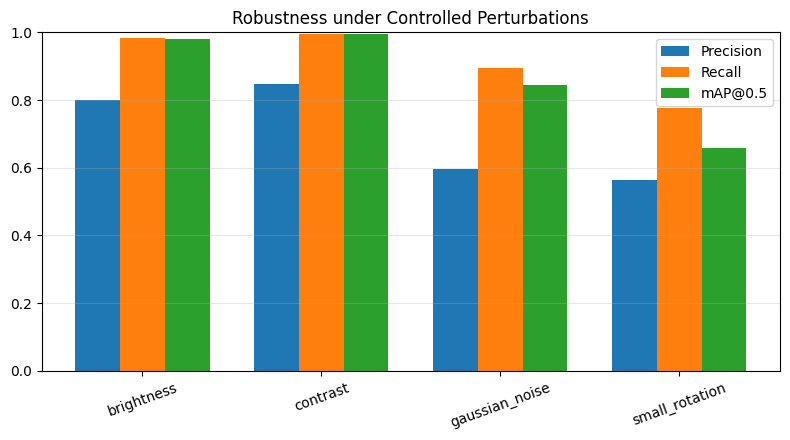

In [ ]:
# ===== 14.1 Robustness visualization =====
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(robustness_df))
width = 0.25
ax.bar(x - width, robustness_df["precision"], width, label="Precision")
ax.bar(x, robustness_df["recall"], width, label="Recall")
ax.bar(x + width, robustness_df["mAP@0.5"], width, label="mAP@0.5")
ax.set_xticks(x); ax.set_xticklabels(robustness_df["perturbation"], rotation=20)
ax.set_ylim(0, 1); ax.set_title("Robustness under Controlled Perturbations")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


## 15. Final Results — Five AI Model Evaluation Criteria

In [ ]:
final_summary = {
    "1. Detection Accuracy": {
        "Precision": round(test_result["precision"], 4),
        "Recall": round(test_result["recall"], 4),
        "mAP@0.5": round(test_result["mAP@0.5"], 4),
        "mAP@0.5:0.95": round(test_result["mAP@0.5:0.95"], 4),
    },
    "2. Inference Speed": {
        "Avg inference time (ms/image)": round(avg_latency_ms, 2),
        "FPS": round(fps, 2),
    },
    "3. Computational Efficiency": {
        "Parameters": f"{n_params:,}",
        "GFLOPs": (round(gflops, 2) if gflops is not None else "not measurable in this environment"),
        "Peak GPU memory (MB, single image)": round(peak_mem_mb, 1),
    },
    "4. Model Size": {
        "File size (MB)": round(model_size_mb, 2),
        "Parameters": f"{n_params:,}",
    },
    "5. Robustness": {
    "Worst-case mAP@0.5 (any perturbation)": round(robustness_df["mAP@0.5"].min(), 4),
    "Mean mAP@0.5 across all perturbations": round(robustness_df["mAP@0.5"].mean(), 4),
    },
}

rows = []
for criterion, metrics in final_summary.items():
    for metric, value in metrics.items():
        rows.append({"Criterion": criterion, "Indicator": metric, "Value": value})

final_df = pd.DataFrame(rows)
print("="*70)
print("FINAL RESULTS -- EfficientDet-Lite0 (tf_efficientdet_lite0) -- Cacao Bean Detection")
print("="*70)
display(final_df)


FINAL RESULTS -- EfficientDet-Lite0 (tf_efficientdet_lite0) -- Cacao Bean Detection


,Criterion,Indicator,Value
0,1. Detection Accuracy,Precision,0.8825
1,1. Detection Accuracy,Recall,0.9972
2,1. Detection Accuracy,mAP@0.5,0.9941
3,1. Detection Accuracy,mAP@0.5:0.95,0.8405
4,2. Inference Speed,Avg inference time (ms/image),25.33
5,2. Inference Speed,FPS,39.48
6,3. Computational Efficiency,Parameters,"3,193,160"
7,3. Computational Efficiency,GFLOPs,6.7
8,3. Computational Efficiency,"Peak GPU memory (MB, single image)",152.9
9,4. Model Size,File size (MB),12.87
